In [2]:
# =============================================================================
# Cell 1: Imports & Setup
# =============================================================================

import os
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import librosa                  # Core library for audio analysis
import librosa.display          # For nice waveform & spectrogram plots
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm           # Progress bar for long loops
import warnings
warnings.filterwarnings("ignore")  # Suppress minor warnings to keep output clean

# Set a clean plotting style
plt.style.use('seaborn-v0_8')
%matplotlib inline

# Define folders (relative to notebook location)
AUDIO_DIR = Path("../data/audio")           
PROCESSED_DIR = Path("../data/processed")   # Where we will save the final CSV
PROCESSED_DIR.mkdir(exist_ok=True)          # Create folder if it doesn't exist

In [3]:
# =============================================================================
# Cell 2: Load all audio files & parse metadata from filenames
# =============================================================================

audio_paths = sorted(glob.glob(str(AUDIO_DIR / "*.*")))
# Keep only common audio formats
audio_paths = [p for p in audio_paths if p.lower().endswith(('.wav', '.mp3', '.m4a', '.ogg'))]

print(f"Found {len(audio_paths)} audio files in {AUDIO_DIR}\n")

# Parse filename into structured metadata
data = []
for p in audio_paths:
    filename = Path(p).stem                  # e.g. "kelvin_yes_approve_01"
    parts = filename.split('_')
    
    # Assume format: person_phrase_index  (e.g. kelvin_confirm_transaction_02)
    person = parts[0] if len(parts) >= 2 else "unknown"
    phrase = "_".join(parts[1:-1]) if len(parts) > 2 else "unknown"
    index  = parts[-1] if len(parts) > 1 else "01"
    
    data.append({
        "person_id": person,
        "phrase": phrase,
        "index": index,
        "path": str(p)          # store as string for easier saving
    })

df_audio = pd.DataFrame(data)
print("First few files:")
display(df_audio.head(10))     # nicer than print for notebooks

Found 6 audio files in ..\data\audio

First few files:


,person_id,phrase,index,path
0,Cynthia,unknown,confirm,..\data\audio\Cynthia_confirm.m4a
1,Cynthia,yes,approve,..\data\audio\Cynthia_yes_approve.m4a
2,kelvin,confirm,tx,..\data\audio\kelvin_confirm_tx.m4a
3,kelvin,yes,approve,..\data\audio\kelvin_yes_approve.m4a
4,nick,confirm,tx,..\data\audio\nick_confirm_tx.m4a
5,nick,yes,approve,..\data\audio\nick_yes_approve.m4a


→ Cynthia | unknown | confirm


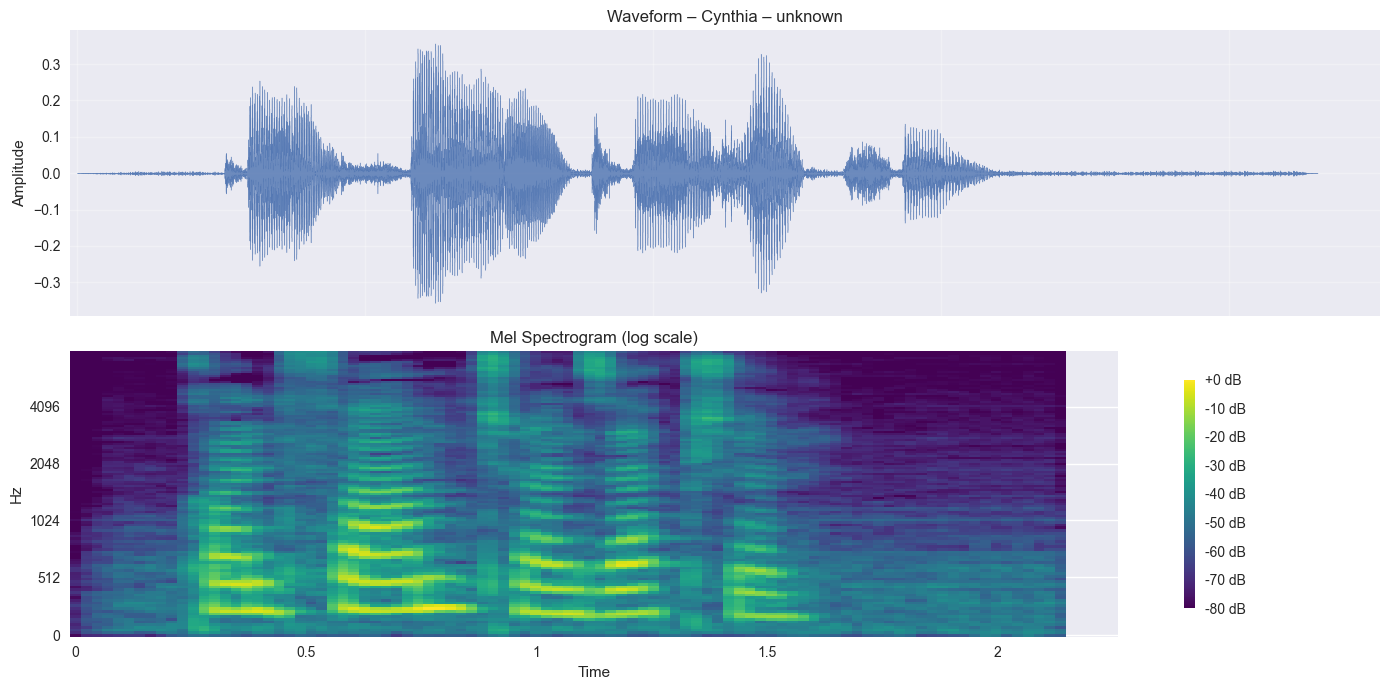

→ Cynthia | yes | approve


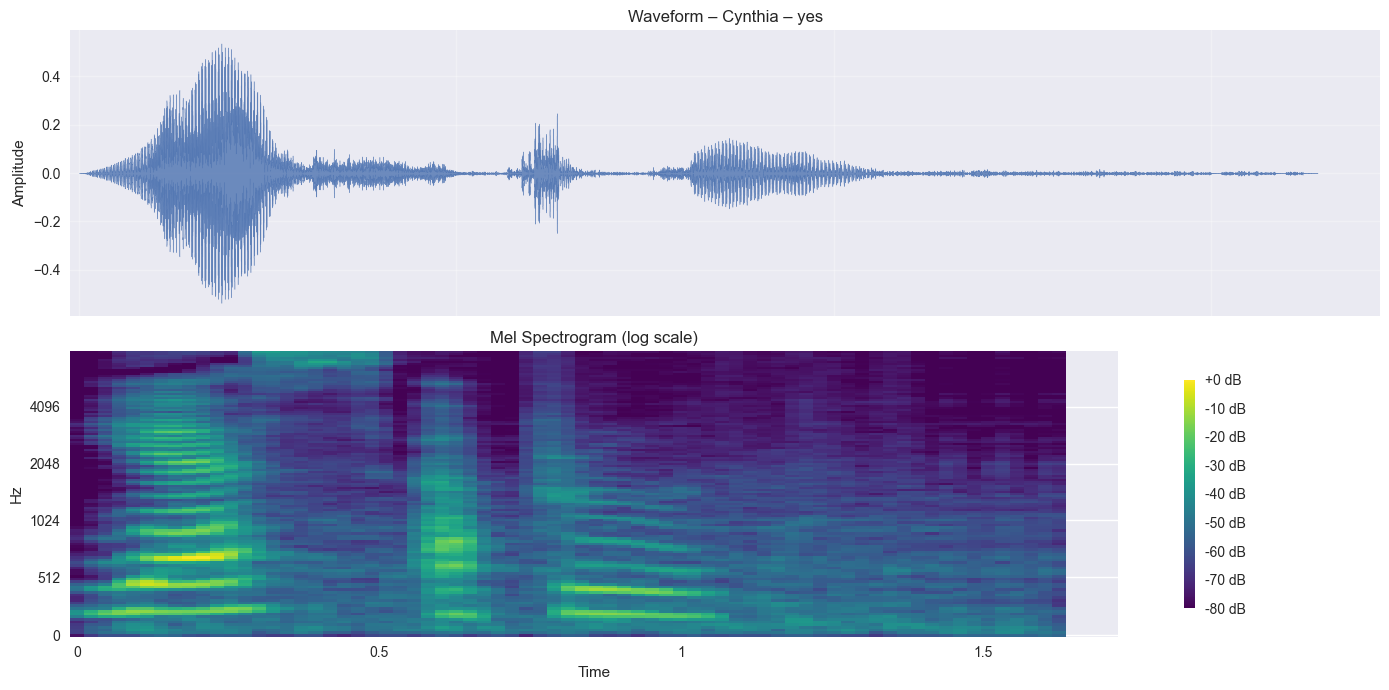

→ kelvin | confirm | tx


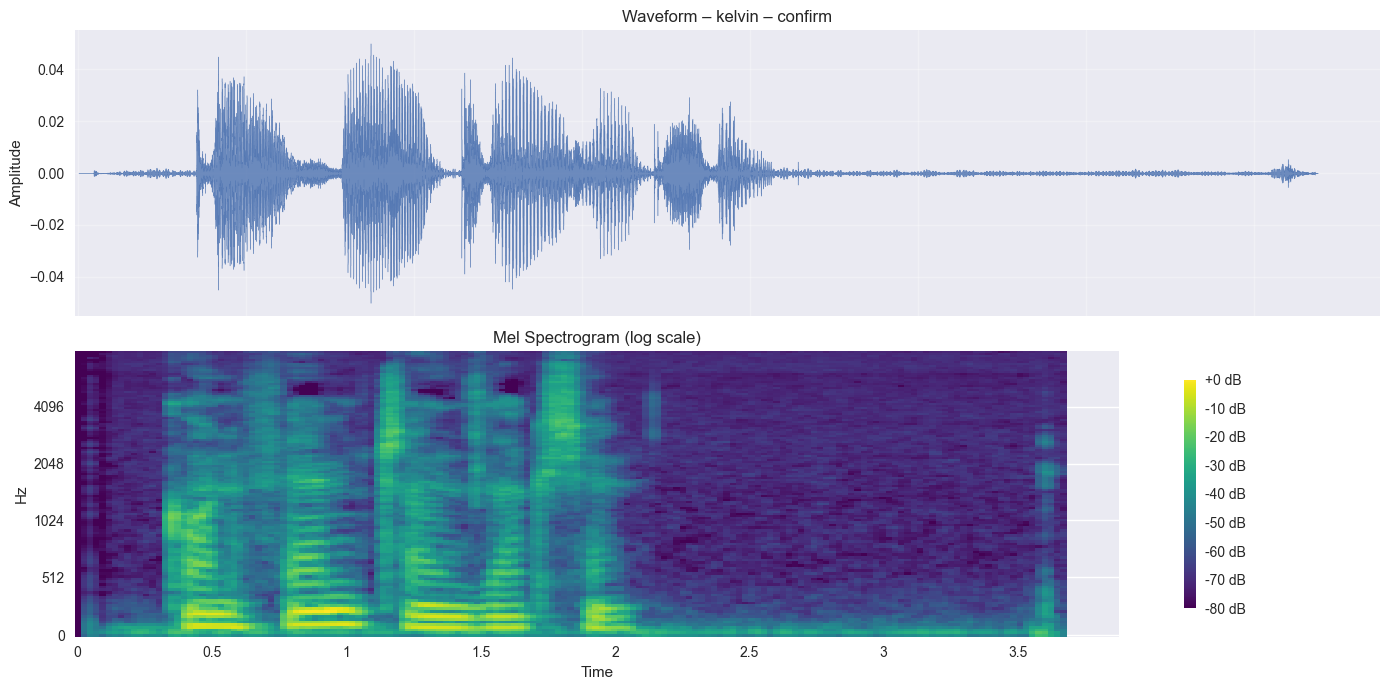

→ kelvin | yes | approve


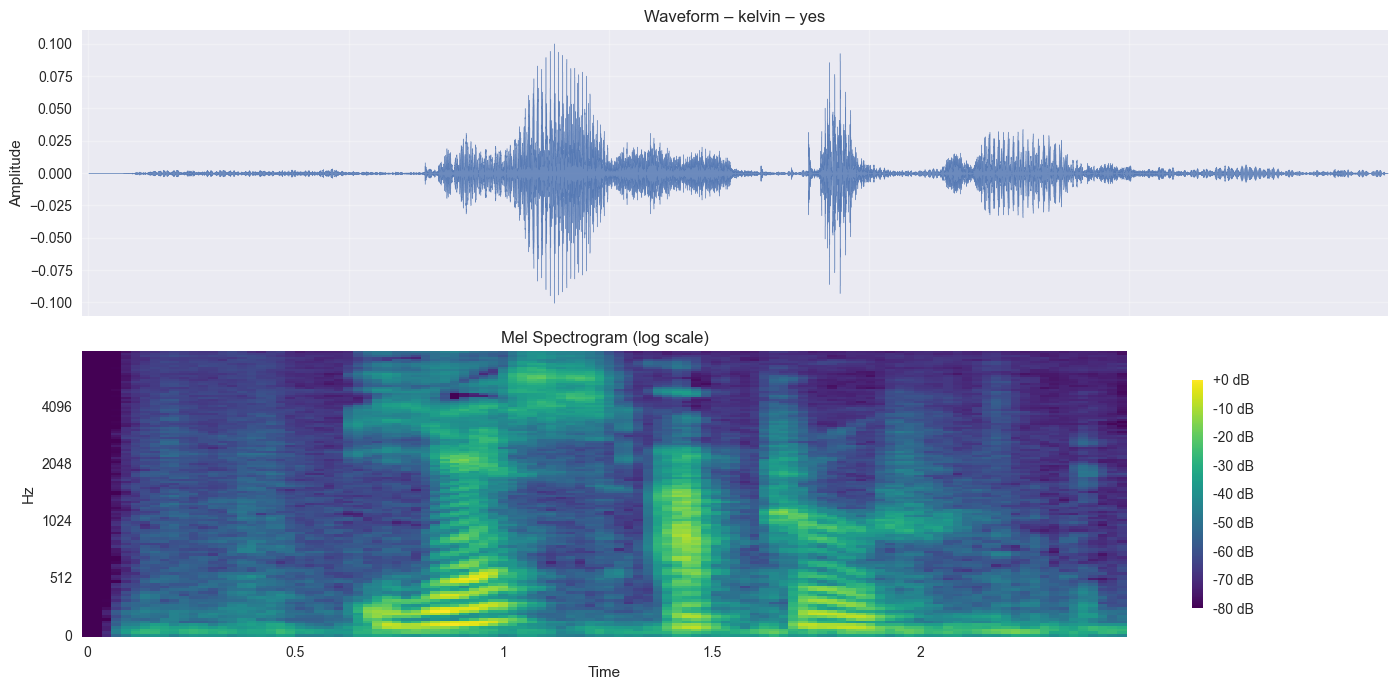

→ nick | confirm | tx


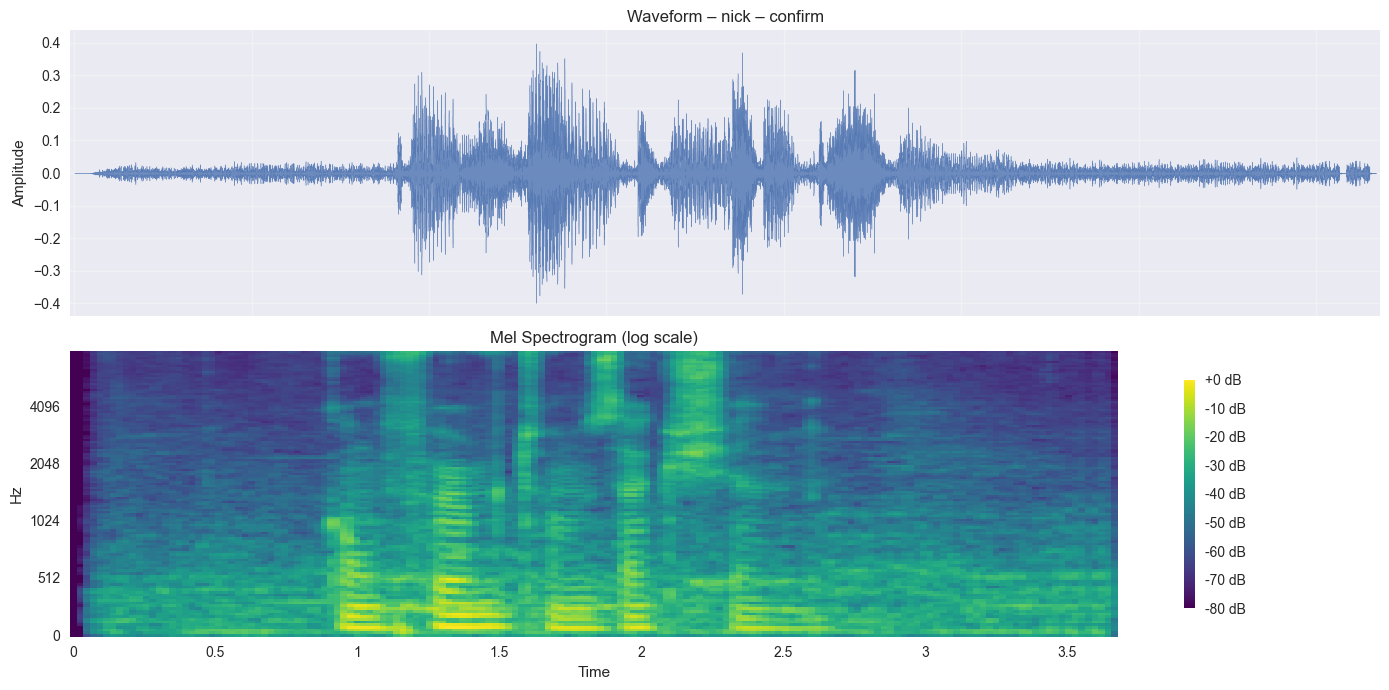

→ nick | yes | approve


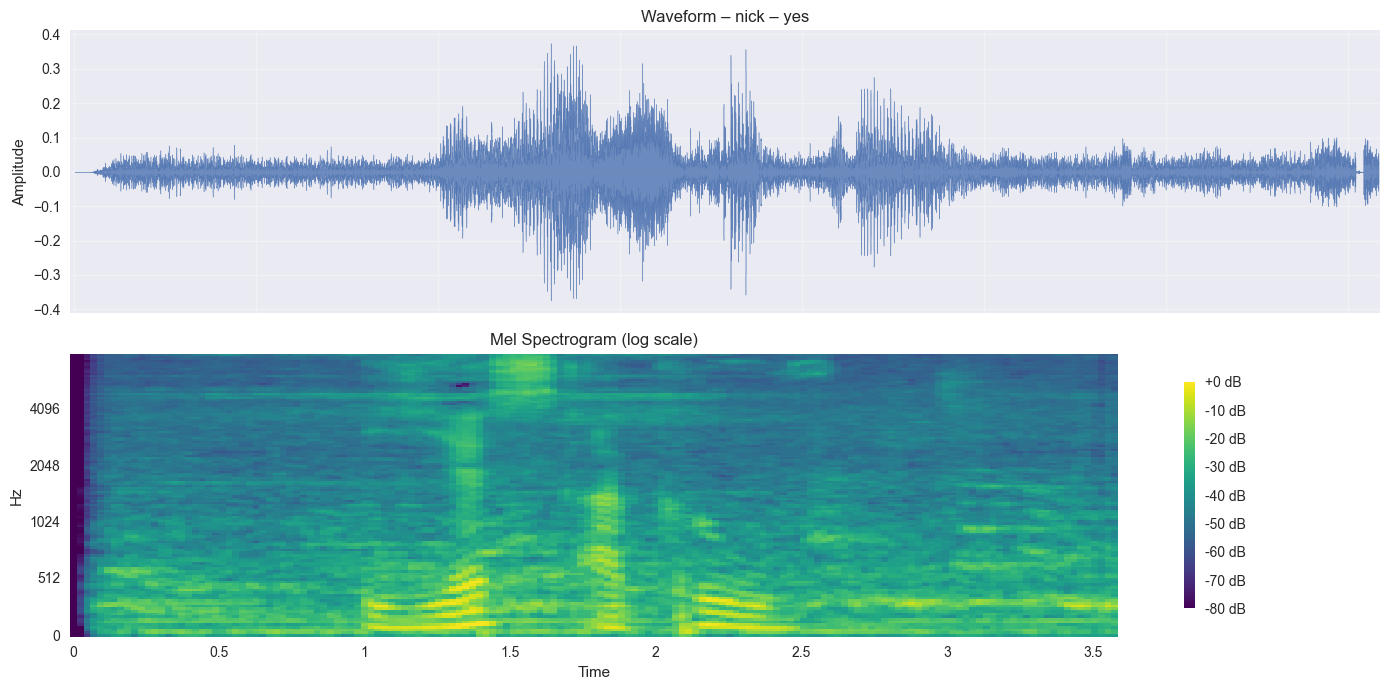

In [4]:
# =============================================================================
# Cell 3: Visualization – Original Waveform + Mel Spectrogram for selected files
# =============================================================================

def plot_waveform_spectrogram(y, sr, title):
    """Plots waveform on top, mel-spectrogram below"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    
    # Waveform plot
    librosa.display.waveshow(y, sr=sr, ax=ax1, alpha=0.8, color='C0')
    ax1.set(title=f"Waveform – {title}",
            ylabel="Amplitude", xlabel=None)
    ax1.grid(True, alpha=0.3)
    
    # Mel-spectrogram (log-scale power)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel',
                                   sr=sr, ax=ax2, fmax=8000, cmap='viridis')
    fig.colorbar(img, ax=ax2, format='%+2.0f dB', shrink=0.8)
    ax2.set(title='Mel Spectrogram (log scale)')
    
    plt.tight_layout()
    plt.show()

# Visualize first 6 files
for _, row in df_audio.head(6).iterrows():
    print(f"→ {row['person_id']} | {row['phrase']} | {row['index']}")
    try:
        y, sr = librosa.load(row['path'], sr=22050)   # consistent 22.05 kHz sample rate
        plot_waveform_spectrogram(y, sr, f"{row['person_id']} – {row['phrase']}")
    except Exception as e:
        print(f"  Could not load {row['path']}: {e}")

In [5]:
# =============================================================================
# Cell 4: Audio Augmentation Functions 
# =============================================================================

def augment_audio(y, sr):
    """Generate 5 versions of the audio signal"""
    versions = {
        "original": y.copy()
    }
    
    # Pitch shift ±2.5 semitones (changes perceived voice pitch)
    versions["pitch_up"]   = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=2.5)
    versions["pitch_down"] = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=-2.5)
    
    # Time stretch (changes speaking speed without pitch change)
    versions["stretch_slow"] = librosa.effects.time_stretch(y=y, rate=0.8)
    versions["stretch_fast"] = librosa.effects.time_stretch(y=y, rate=1.25)
    
    # Add very light Gaussian noise (simulates background/room noise)
    noise = np.random.normal(0, 0.005, len(y))
    versions["noisy"] = y + noise
    
    return versions

In [6]:
# =============================================================================
# Cell 5: Rich Feature Extraction (MFCCs + deltas + spectral + energy)
# =============================================================================

def extract_audio_features(y, sr, n_mfcc=20):
    """Extract ~120–140 features per audio clip"""
    features = {}
    
    # 1. MFCCs (20 coefficients) + first & second order derivatives
    mfcc       = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta_mfcc = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)
    
    # Compute mean & std for each coefficient (very important for speaker ID)
    for i in range(n_mfcc):
        features[f"mfcc_mean_{i}"]   = np.mean(mfcc[i])
        features[f"mfcc_std_{i}"]    = np.std(mfcc[i])
        features[f"delta_mean_{i}"]  = np.mean(delta_mfcc[i])
        features[f"delta_std_{i}"]   = np.std(delta_mfcc[i])
        features[f"delta2_mean_{i}"] = np.mean(delta2_mfcc[i])
        features[f"delta2_std_{i}"]  = np.std(delta2_mfcc[i])
    
    # 2. Spectral shape features (averaged over time)
    features["spectral_centroid_mean"] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)[0])
    features["spectral_rolloff_mean"]  = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)[0])
    features["spectral_bandwidth_mean"] = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)[0])
    
    # 3. Zero-crossing rate (how often signal changes sign – related to noisiness)
    features["zero_crossing_rate_mean"] = np.mean(librosa.feature.zero_crossing_rate(y)[0])
    
    # 4. RMS energy (loudness variation)
    rms = librosa.feature.rms(y=y)[0]
    features["rms_mean"] = np.mean(rms)
    features["rms_std"]  = np.std(rms)
    
    return features

In [7]:
# =============================================================================
# Cell 6: Main Processing Loop – Extract features from all originals + augmentations
# =============================================================================

all_audio_features = []

for _, row in tqdm(df_audio.iterrows(), total=len(df_audio), desc="Extracting audio features"):
    try:
        # Load audio at fixed sample rate
        y, sr = librosa.load(row["path"], sr=22050)
        
        # Generate augmented versions
        aug_versions = augment_audio(y, sr)
        
        # Extract features for each version
        for aug_name, y_aug in aug_versions.items():
            feats = extract_audio_features(y_aug, sr)
            
            # Build one row in the final dataset
            record = {
                "person_id": row["person_id"],
                "phrase": row["phrase"],
                "original_index": row["index"],
                "augmentation": aug_name,
                "original_path": row["path"],
                **feats   # unpack all extracted features
            }
            all_audio_features.append(record)
            
    except Exception as e:
        print(f"  Error on {row['path']}: {e}")

# Convert list of dicts → DataFrame
df_features = pd.DataFrame(all_audio_features)

print(f"\n Created dataset with {len(df_features)} rows × {df_features.shape[1]} columns")
print(f"   → {df_features['person_id'].nunique()} unique speakers")
print(f"   → {df_features['augmentation'].nunique()} versions per original")

Extracting audio features: 100%|██████████| 6/6 [00:23<00:00,  3.87s/it]


 Created dataset with 36 rows × 131 columns
   → 3 unique speakers
   → 6 versions per original


In [14]:
# =============================================================================
# Cell 7: Quick Quality Check
# =============================================================================

print("Sample columns:", df_features.columns.tolist()[:20], "...and more")
print("\nSpeakers found:", df_features["person_id"].unique())
print("\nAugmentation distribution:\n", df_features["augmentation"].value_counts())

# Show first 3 rows (wide table, but useful)
display(df_features.head(3))

Sample columns: ['person_id', 'phrase', 'original_index', 'augmentation', 'original_path', 'mfcc_mean_0', 'mfcc_std_0', 'delta_mean_0', 'delta_std_0', 'delta2_mean_0', 'delta2_std_0', 'mfcc_mean_1', 'mfcc_std_1', 'delta_mean_1', 'delta_std_1', 'delta2_mean_1', 'delta2_std_1', 'mfcc_mean_2', 'mfcc_std_2', 'delta_mean_2'] ...and more

Speakers found: <StringArray>
['Cynthia', 'kelvin', 'nick']
Length: 3, dtype: str

Augmentation distribution:
 augmentation
original        6
pitch_up        6
pitch_down      6
stretch_slow    6
stretch_fast    6
noisy           6
Name: count, dtype: int64


,person_id,phrase,original_index,augmentation,original_path,mfcc_mean_0,mfcc_std_0,delta_mean_0,delta_std_0,delta2_mean_0,...,delta_mean_19,delta_std_19,delta2_mean_19,delta2_std_19,spectral_centroid_mean,spectral_rolloff_mean,spectral_bandwidth_mean,zero_crossing_rate_mean,rms_mean,rms_std
0,Cynthia,unknown,confirm,original,..\data\audio\Cynthia_confirm.m4a,-354.307281,114.957275,0.885840,14.221992,-0.529130,...,0.038743,0.830628,0.018363,0.613595,1936.435599,3696.070123,2051.653087,0.105217,0.041042,0.041115
1,Cynthia,unknown,confirm,pitch_up,..\data\audio\Cynthia_confirm.m4a,-375.633362,119.844841,0.671885,14.000022,-0.585624,...,0.017359,1.567197,-0.044554,0.703150,2162.817732,4407.476216,2315.120704,0.115051,0.028154,0.026855
2,Cynthia,unknown,confirm,pitch_down,..\data\audio\Cynthia_confirm.m4a,-391.301422,117.075836,0.714238,13.312626,-0.593632,...,-0.008347,0.990544,-0.034462,0.563580,1732.969506,3516.163684,1898.690070,0.093829,0.026363,0.027086


In [17]:
# =============================================================================
# Cell 8: Save the final feature file
# =============================================================================

save_path = PROCESSED_DIR / "audio_features.csv"
df_features.to_csv(save_path, index=False)

print(f" Audio features saved to: {save_path}")
print(f"   Shape: {df_features.shape}")
print(f"   File size: ~{os.path.getsize(save_path)/1024/1024:.1f} MB")

 Audio features saved to: ..\data\processed\audio_features.csv
   Shape: (36, 131)
   File size: ~0.1 MB


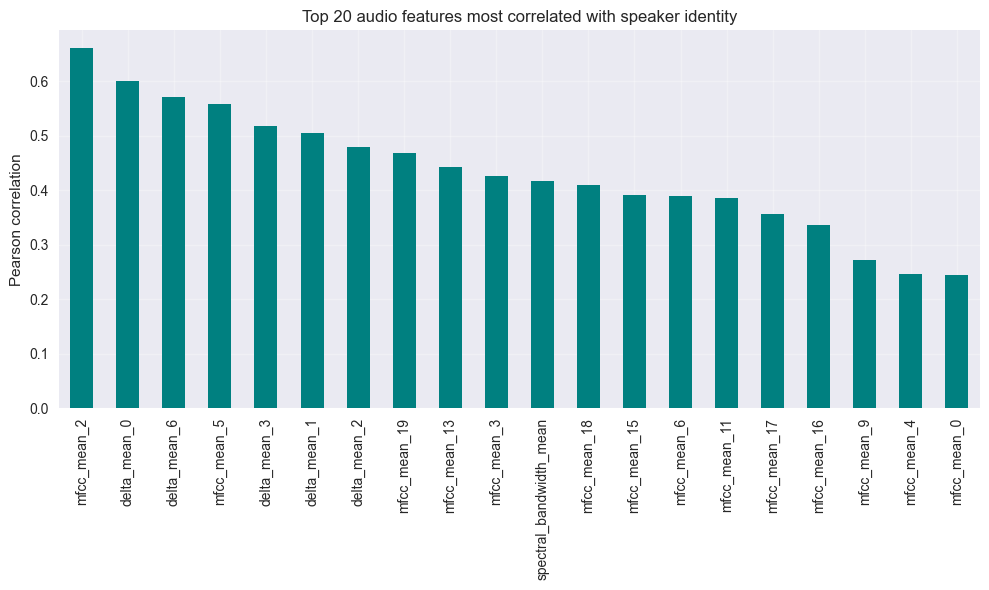

In [18]:
# =============================================================================
# Cell 9: Which features best distinguish speakers? (correlation view)
# =============================================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_features["person_label"] = le.fit_transform(df_features["person_id"])

# Select only numeric feature columns
feature_cols = [c for c in df_features.columns if c.startswith(("mfcc_", "delta_", "spectral_", "rms_", "zero_"))]

# Correlation with speaker label
corr = df_features[feature_cols + ["person_label"]].corr()["person_label"].drop("person_label")
corr = corr.sort_values(ascending=False)

# Plot top 20 most discriminative features
plt.figure(figsize=(10, 6))
corr.head(20).plot(kind="bar", color="teal")
plt.title("Top 20 audio features most correlated with speaker identity")
plt.ylabel("Pearson correlation")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Train size: 27, Test size: 9
Classes: ['Cynthia' 'kelvin' 'nick']

Accuracy: 1.000
F1-score (weighted): 1.000

Classification Report:
              precision    recall  f1-score   support

     Cynthia       1.00      1.00      1.00         3
      kelvin       1.00      1.00      1.00         3
        nick       1.00      1.00      1.00         3

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



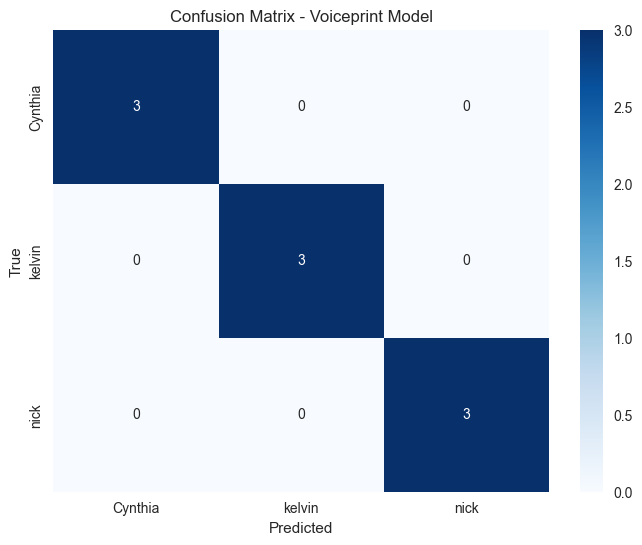

In [19]:
# =============================================================================
# Quick Voiceprint Baseline Model
# =============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
feature_cols = [c for c in df_features.columns if c.startswith(('mfcc_', 'delta_', 'spectral_', 'rms_', 'zero_'))]

X = df_features[feature_cols].copy()
y = df_features['person_id']

# Scale features (very important for many classifiers)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode labels if needed (already strings, but good practice)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split (stratified to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.25, stratify=y_encoded, random_state=42
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Classes: {le.classes_}")

# Train simple Random Forest
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=3,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)

# Predict & evaluate
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nAccuracy: {acc:.3f}")
print(f"F1-score (weighted): {f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Voiceprint Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [20]:
import joblib

joblib.dump(clf, '../models/voice_model_rf.joblib')
joblib.dump(scaler, '../models/voice_scaler.joblib')
joblib.dump(le, '../models/voice_label_encoder.joblib')

print("Voice model, scaler, and encoder saved.")

Voice model, scaler, and encoder saved.
